# Star catalogue for F-CAMs

In preparation of the scvPIC, we need prepare a list of 300 stars for observations with PLATO F-CAMs. The main idea behind this sample is to thoroughly test and improve theory of stellar structure and evolution across the HRD. The sample needs to be prepared by the upcoming Monday, and we need your help on this front. To begin with, could you please select stars with $P \leq 10$ from your Gaia magnitude-limited catalog in LOPS2. Then, from the resulting sub-sample, could you please select the following categories using classifications as listed in Simbad:

- Blue supergiants
- Asymptotic Giant Branch (AGB) stars
- Post Asymptotic Giant Branch (post-AGB) stars
- Contact/interacting binaries, spectral types O and B
- Algol-type binaries

It would be fabulous if you could deliver the lists by the end of this week. It will suffice if these lists contain the following columns: 1) Gaia DR3 ID, 2) RA & DEC, 3) G-band magnitude

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [291]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
from platosim.matplotlibrc import setup_paper
setup_paper(warning=False)

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important;}</style>"))

In [269]:
# Define paths used throughout
path = Path(os.getenv('PLATO_WORKDIR')) / 'PlatoCS'
fdir = path / 'plots'

# Use seed for reproducebility
seed = 12345
rng = ut.rng(seed)

## Load PLATO-CS F-CAM catalogue

In [292]:
# Load F-CAM catalogue
df = pd.read_feather(path / 'starcat_Gmag17' / 'starcat_GaiaDR3_FCAM_LOPS2.ftr')

In [293]:
# Fetch bright stars
dt = df[df.Pmag <= 10].reset_index(drop=True)
dt

,gaiaDR3,ra,dec,Gmag,BP_RP,Ag,plx,plx_err,pmra,pmdec,...,S_err,spec,evol,variable,class,ncams,Pmag,Pgiant,PBmag,PRmag
0,5502164890740285696,102.484267,-50.614848,2.618499,1.312425,NaN,18.757713,0.347519,32.618184,-69.565734,...,NaN,G,<NA>,NOT_AVAILABLE,,6,2.282788,2.277100,2.718279,1.864839
1,2896572746685604480,95.078337,-30.063349,3.007651,0.069759,NaN,9.492206,0.447933,6.084451,4.247413,...,NaN,B,<NA>,NOT_AVAILABLE,,6,2.982762,2.982928,2.998538,2.960518
2,5478862906452936960,102.047058,-61.940116,3.203374,0.458191,NaN,NaN,NaN,NaN,NaN,...,NaN,A,<NA>,NOT_AVAILABLE,,6,3.053324,3.053446,3.168014,2.906023
3,5557271829408912896,99.440299,-43.195953,3.175233,0.098825,NaN,8.819389,0.288251,-0.537264,-3.858982,...,NaN,B,<NA>,NOT_AVAILABLE,,6,3.140169,3.140392,3.162667,3.108633
4,4757601523650165120,83.406311,-62.489769,3.593462,1.049574,0.3925,2.930785,0.139114,-0.611187,12.949733,...,NaN,F,<NA>,NOT_AVAILABLE,,6,3.302200,3.298827,3.620285,2.965348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10598,5584346478612101632,100.998162,-31.008730,10.316176,1.193816,0.0672,1.135327,0.011311,-6.656720,10.248847,...,NaN,K,535,NOT_AVAILABLE,,6,9.999259,9.994634,10.379486,9.617524
10599,4798390759342432256,78.107275,-46.434985,10.182138,0.575311,0.0258,3.907931,0.121519,-8.328669,-3.295377,...,0.000362,F,241,NOT_AVAILABLE,,6,9.999308,9.999040,10.148478,9.814130
10600,5510292476394480000,109.951475,-46.716009,10.300538,1.102177,0.2281,2.793636,0.024651,15.949678,-15.022922,...,0.000521,K,513,NOT_AVAILABLE,,6,9.999551,9.995729,10.339667,9.646235
10601,4800320844628782848,81.085860,-44.243531,10.306399,1.134141,0.0720,0.995630,0.011141,3.556520,15.742077,...,NaN,K,514,NOT_AVAILABLE,,6,9.999711,9.995612,10.353567,9.636443


In [184]:
# Fetch OTYPE of Simbad to assemble catalogue
for i in tqdm(range(dt.shape[0]), bar_format=ut.tqdmBar()):
    di = sq.simbadQuery(f'Gaia DR3 {dt.gaiaDR3.iloc[i]}')
    if i == 0: dq = di
    else: dq = pd.concat([dq, di])

100%|██████████████████████████████████████████████████| 10603/10603 [00:53<00:00, 197.33it/s]                                                                                                              


In [185]:
# Correct data frame
dq = dq.reset_index(drop=True)
dt['otype'] = dq.otype
dt.insert(0, 'source', dq.source)
dt = dt.drop(columns='ncams')

The following OTYPE names are used:

- Blue supergiants: `BlueSG`
- Asymptotic Giant Branch (AGB) stars: `AGB*`
- Post Asymptotic Giant Branch (post-AGB) stars: `post-AGB*`
- Contact/interacting binaries, spectral types O and B: ``
- Algol-type binaries: `Al*`

Reference: `https://simbad.cds.unistra.fr/Pages/guide/otypes.htx`

In [288]:
# Save catalogue
dt.to_feather(path / 'starcat_Gmag17' / 'starcat_GaiaDR3_FCAM_LOPS2_Pmax10.ftr')

In [186]:
dq[dq.otype == 'BlueSG']

,source,ra,dec,otype
23,* J Pup,07:53:18.1574,-48:06:10.566,BlueSG


In [187]:
dq[dq.otype == 'AGB*']

,source,ra,dec,otype


In [188]:
dq[dq.otype == 'post-AGB*']

,source,ra,dec,otype
8281,V* ST Pup,06:48:56.4136,-37:16:33.338,post-AGB*


In [189]:
dq[dq.otype == '**']

,source,ra,dec,otype
17,* P Pup,07:49:14.2975,-46:22:23.518,**
37,HD 62644,07:42:57.0956,-45:10:23.215,**
79,CD-35 2947,06:31:13.0934,-35:15:31.886,**
97,HD 44267,06:17:51.7446,-52:43:58.912,**
99,* pi.02 Col,06:07:52.8595,-42:09:14.548,**
...,...,...,...,...
9821,HD 273884,05:15:23.2353,-48:06:07.036,**
9965,CD-53 1537,06:37:11.8152,-53:28:21.813,**
10021,GSC 07091-02246,06:44:01.2732,-33:38:02.772,**
10422,CD-51 1948,06:31:29.0011,-52:00:20.374,**


In [216]:
dt_BlueSG  = dt[dt.otype == 'BlueSG']
dt_AGB     = dt[dt.otype == 'AGB*']
dt_postAGB = dt[dt.otype == 'post-AGB*']
dt_binary  = dt[dt.otype == '**']

### Cross-match with EBs (IJspeert+2024)

In [233]:
# Download file from FTP
ut.downloadFromFTP('table_OBAF_EB_catalogue.csv')

In [252]:
# Load catalogue
idir = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles'
db = pd.read_csv(idir / 'table_OBAF_EB_catalogue.csv')

In [284]:
# Cross-match with Luc's catalogue
dt.gaiaDR3 = dt.gaiaDR3.astype(float)
db0 = db[db['GAIA_DR3'].isin(dt['gaiaDR3'])].sort_values(by=['GAIA_DR3']).reset_index(drop=True)
dt0 = dt[dt['gaiaDR3'].isin(db['GAIA_DR3'])].sort_values(by=['gaiaDR3']).reset_index(drop=True)

In [287]:
# Select B stars (no O stars are available)
dt_EBs = dt0[dt0.spec == 'B']
dt_EBs

,gaiaDR3,ra,dec,Gmag,BP_RP,Ag,plx,plx_err,pmra,pmdec,...,S_err,spec,evol,variable,class,ncams,Pmag,Pgiant,PBmag,PRmag
0,2.885868e+18,92.587969,-35.768969,8.788738,0.053745,0.3025,0.915993,0.301457,0.784312,9.045414,...,NaN,B,221,VARIABLE,,6,8.769506,8.769637,8.781616,8.752376
8,4.765835e+18,87.540958,-56.806205,9.226493,0.486615,NaN,3.958614,0.027329,16.469447,27.691773,...,NaN,B,<NA>,VARIABLE,,6,9.068267,9.068312,9.191097,8.911773
17,5.284088e+18,93.914507,-66.292205,7.300951,-0.115051,0.1363,2.815581,0.040132,3.354343,13.864270,...,NaN,B,220,NOT_AVAILABLE,,6,7.343311,7.342971,7.318269,7.379797
18,5.476504e+18,91.962519,-65.278304,9.679218,-0.094018,NaN,0.437212,0.028383,2.645284,4.951146,...,NaN,B,<NA>,NOT_AVAILABLE,,6,9.713723,9.713449,9.693177,9.743559
19,5.478304e+18,97.794243,-61.879488,6.115168,-0.216528,NaN,2.233210,0.058839,-9.356483,12.212107,...,NaN,B,<NA>,VARIABLE,,6,6.196030,6.195364,6.149734,6.264480
22,5.492199e+18,113.192223,-53.555205,6.989336,-0.110279,0.2109,1.933696,0.042088,-8.223216,8.207318,...,NaN,B,278,VARIABLE,,6,7.029911,7.029585,7.005885,7.064888
31,5.499416e+18,92.574590,-54.968607,4.720275,-0.343440,0.0001,2.150274,0.151614,-3.754010,8.093400,...,NaN,B,<NA>,VARIABLE,,6,4.850370,4.849355,4.778339,4.958509
36,5.506361e+18,114.585457,-48.670003,9.393840,0.102518,0.7268,1.271150,0.016963,-3.726071,5.793441,...,NaN,B,185,VARIABLE,,6,9.357491,9.357721,9.380850,9.324774
37,5.507070e+18,110.215801,-48.514045,8.375094,0.008741,0.1964,3.031784,0.020923,-4.314415,12.168381,...,NaN,B,191,VARIABLE,,6,8.371941,8.371964,8.373891,8.369158
40,5.508885e+18,107.102178,-47.520888,9.260121,-0.032210,0.1400,1.369963,0.020752,-3.251137,7.130540,...,NaN,B,244,NOT_AVAILABLE,,6,9.271825,9.271736,9.264699,9.282065


### Plot star in sky

<IPython.core.display.Javascript object>


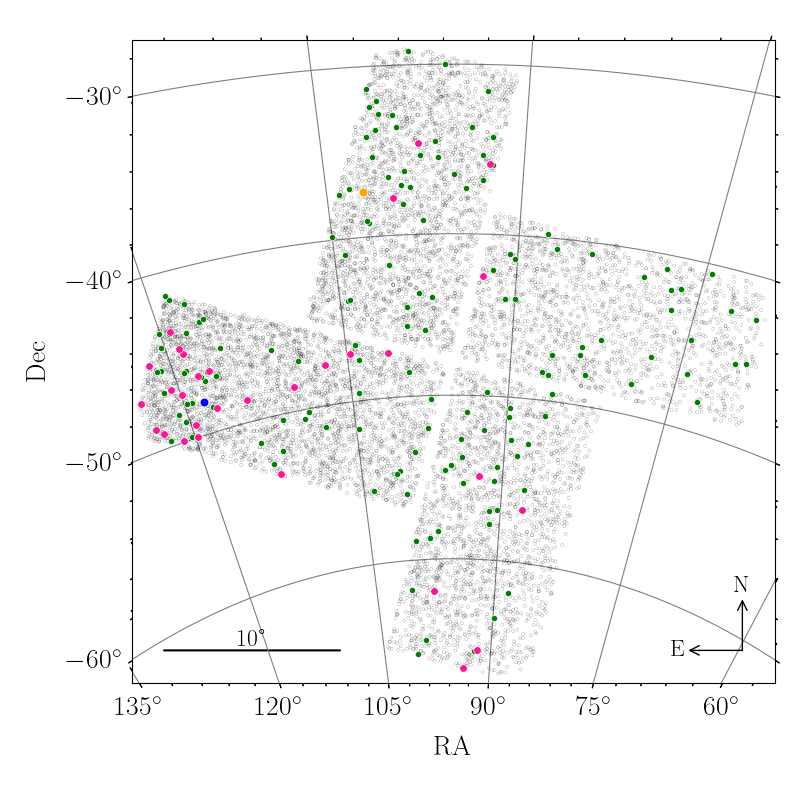

In [295]:
# Show pointign field
fig, ax = pt.plotPlatoFOV('LOPS2', raStars=dt.ra, decStars=dt.dec,
                          showGroups=False, showFcamFOV=False, 
                          fovSize=20, fs=20, ms=5, figsize=(8,8))

# Plot requested variable stars
zorder = 10
ax.scatter(dt_double.ra, dt_double.dec, s=20, marker='o', edgecolor='w', facecolor='green',
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
ax.scatter(dt_EBs.ra, dt_EBs.dec, s=20, marker='o', edgecolor='w', facecolor='deeppink', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
ax.scatter(dt_BlueSG.ra, dt_BlueSG.dec, s=40, marker='o', edgecolor='w', facecolor='blue', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
# ax.scatter(dt_AGB.ra, dt_AGB.dec, s=40, marker='o', edgecolor='w', facecolor='tomato', 
#            linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)
ax.scatter(dt_postAGB.ra, dt_postAGB.dec, s=40, marker='o', edgecolor='w', facecolor='orange', 
           linewidth=0.5, transform=ax.get_transform('world'), zorder=zorder)

fig.savefig(fdir / 'starcat_GaiaDR3_FCAM_LOPS2.png', bbox_inches='tight', dpi=300);